# Does the Binary Collapse Depend on the Feeding Strategy?

The earlier 2-D demo used `diversity_mode="c_spread"` — which Experiment 2 identified as the **worst**
feeding strategy, because the $m$ \glspl{svm} differ only by their regularisation constant and end up
collinear. A fair objection: maybe the binary rank-1 collapse and the flat depth curve are artefacts of
c_spread, not intrinsic to binary depth.

This notebook tests that directly. It re-runs the same diagnostics under three feeding strategies on the
*same* binary moons and three-class blobs:

- `c_spread` — the Experiment-2 loser (collinear \glspl{svm}).
- `disjoint` — **Instance Partitioning**, an Experiment-2 winner (avg rank 1.81).
- `disjoint_featpart` — **Feature Partitioning**, the top Experiment-2 winner (avg rank 1.63).

For each we measure, per block: the stable rank of the inter-layer representation, the mean pairwise
$|\cos|$ between the \gls{svm} weight vectors, and the per-layer head accuracy. The decisive question:
**does depth still fail on binary under the good strategies, or only under c_spread?**

> Run from `experiments/` (imports `ml_msvm`, `mlsvm_extensions`).

In [1]:
import os

os.chdir("..")
import numpy as np, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

# Import your architecture
from mlsvm_extensions import DiverseMLMSVM, _InputSubspaceBlock


def make_clean_checkerboard(n_samples):
    rng = np.random.default_rng(42)
    X = rng.uniform(0, 4, size=(n_samples, 2))
    coords = np.floor(X).astype(int)
    y = (np.sum(coords, axis=1) % 2).astype(int)
    return X, y

def make_spirals(n_samples, turns=2.5, noise=0.05):
    rng = np.random.default_rng(42)
    n = np.sqrt(rng.uniform(0, 1, size=(n_samples, 1))) * turns * (2 * np.pi)
    d1x = -np.cos(n) * n + rng.standard_normal((n_samples, 1)) * noise
    d1y = np.sin(n) * n + rng.standard_normal((n_samples, 1)) * noise
    X0 = np.hstack([d1x, d1y])
    X1 = np.hstack([-d1x, -d1y])
    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n_samples), np.ones(n_samples)]).astype(int)
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

M, L, P, SEED = 10, 3, 500, 0
STRATEGIES = [("c_spread", "c_spread (Exp-2 loser)"),
              ("disjoint", "Instance Partitioning (winner)"),
              ("disjoint_featpart", "Feature Partitioning (winner)")]

# Generate 2000 points for a clean visualization
Xc, yc = make_clean_checkerboard(2000)
Xs, ys = make_spirals(1000)  # 1000 per class = 2000 total

print("Datasets ready: Checkerboard and Spirals")

Datasets ready: Checkerboard and Spirals


In [2]:
def build(X, y, strat):
    return Pipeline([("scaler", StandardScaler()),
        ("clf", DiverseMLMSVM(num_layers=L, svms_per_block=M, rff_features=P,
            kernel="arc_cosine", arc_cosine_degree=1, diversity_mode=strat,
            block_C=10.0, final_C=1.0, random_state=SEED,
            normalize_inter_layer=True))]).fit(X, y)

def reps_and_W(model, X):
    """Per-layer representations [X^0..X^L] and per-block W."""
    clf = model.named_steps["clf"]; sc = model.named_steps["scaler"]
    Xc = sc.transform(X); R = [Xc.copy()]; Ws = []
    for b in clf.blocks_:
        if isinstance(b, _InputSubspaceBlock):
            pj = []
            for (cols, Om, bb, Wj) in b.sub_models:
                Phi = clf._feature_map(Xc[:, cols], Om, bb, kernel=b.kernel,
                                       arc_cosine_degree=b.arc_cosine_degree)
                pj.append(Phi @ Wj)
            Xn = np.hstack(pj); Ws.append(None)
        else:
            Phi = clf._feature_map(Xc, b.Omega, b.b, kernel=b.kernel,
                                   arc_cosine_degree=b.arc_cosine_degree)
            Xn = Phi @ b.W; Ws.append(b.W)
        if getattr(b, "scaler", None) is not None: Xn = b.scaler.transform(Xn)
        R.append(Xn); Xc = Xn
    return R, Ws

def stable_rank(X):
    s = np.linalg.svd(X - X.mean(0), compute_uv=False)
    return float((s**2).sum() / (s[0]**2)) if s[0] > 0 else 0.0

def head_acc(R, y):
    """Per-layer accuracy: a linear SVM on each layer's representation (70/30 split)."""
    n = len(y); tr = int(0.7*n); idx = np.random.RandomState(0).permutation(n)
    tri, tei = idx[:tr], idx[tr:]; accs = []
    for Xl in R[1:]:
        clf = LinearSVC(C=1.0, max_iter=3000, tol=1e-3).fit(Xl[tri], y[tri])
        accs.append(clf.score(Xl[tei], y[tei]))
    return accs


=== CHECKERBOARD ===
strategy                         |        rank L1-3 |               acc L1-3
------------------------------------------------------------------------------
c_spread (Exp-2 loser)           |   1.20 1.01 1.00 |      0.755 0.825 0.830
Instance Partitioning (winner)   |   1.09 1.17 1.08 |      0.760 0.855 0.897
Feature Partitioning (winner)    |   1.35 1.15 1.09 |      0.733 0.783 0.817

=== SPIRALS ===
strategy                         |        rank L1-3 |               acc L1-3
------------------------------------------------------------------------------
c_spread (Exp-2 loser)           |   1.00 1.00 1.00 |      0.600 0.602 0.602
Instance Partitioning (winner)   |   1.56 2.25 1.41 |      0.598 0.615 0.913
Feature Partitioning (winner)    |   1.29 1.48 1.45 |      0.595 0.537 0.837


In [4]:
def block_scores_on_grid(model, grid, block_idx):
    clf = model.named_steps["clf"]
    sc = model.named_steps["scaler"]
    Xc = sc.transform(grid)
    for i, b in enumerate(clf.blocks_):
        if isinstance(b, _InputSubspaceBlock):
            pj = []
            for (cols, Om, bb, Wj) in b.sub_models:
                Phi = clf._feature_map(Xc[:, cols], Om, bb, kernel=b.kernel,
                                       arc_cosine_degree=b.arc_cosine_degree)
                pj.append(Phi @ Wj)
            out = np.hstack(pj)
            Xn = out
        else:
            Phi = clf._feature_map(Xc, b.Omega, b.b, kernel=b.kernel,
                                   arc_cosine_degree=b.arc_cosine_degree)
            out = Phi @ b.W
            Xn = out
        if i == block_idx: 
            return out
        if getattr(b, "scaler", None) is not None: 
            Xn = b.scaler.transform(Xn)
        Xc = Xn
    return None

def rep_2d(R, layer):
    Rr = R[layer]
    if Rr.shape[1] == 1: 
        return np.column_stack([Rr[:,0], np.zeros(len(Rr))])
    Rc = Rr - Rr.mean(0)
    _, _, Vt = np.linalg.svd(Rc, full_matrices=False)
    return Rc @ Vt[:2].T

def draw(X, y, kind, fname, suptitle):
    fig, axes = plt.subplots(len(STRATEGIES), 3, figsize=(13, 4*len(STRATEGIES)))
    xx, yy = np.meshgrid(np.linspace(X[:,0].min()-.5, X[:,0].max()+.5, 200),
                         np.linspace(X[:,1].min()-.5, X[:,1].max()+.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    
    for r, (strat, name) in enumerate(STRATEGIES):
        m = build(X, y, strat)
        R, _ = reps_and_W(m, X)
        
        for c, blk in enumerate([0, 2]):
            ax = axes[r][c]
            ax.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", s=6, alpha=.3, edgecolors="none")
            S = block_scores_on_grid(m, grid, blk)
            for j in range(S.shape[1]):
                ax.contour(xx, yy, S[:,j].reshape(xx.shape), levels=[0],
                           colors="k", linewidths=0.8, alpha=0.45)
            ax.set_title(f"{name}\nblock {blk+1}: {M} boundaries", fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            
        ax = axes[r][2]
        Pp = rep_2d(R, L)
        ax.scatter(Pp[:,0], Pp[:,1], c=y, cmap="coolwarm", s=6, alpha=.5, edgecolors="none")
        ax.set_title(f"{name}\nrepresentation after block {L} (top-2 PCs)", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
        
    fig.suptitle(suptitle, y=1.005, fontsize=11)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches="tight", dpi=130)
    plt.show()
    print("saved", fname)

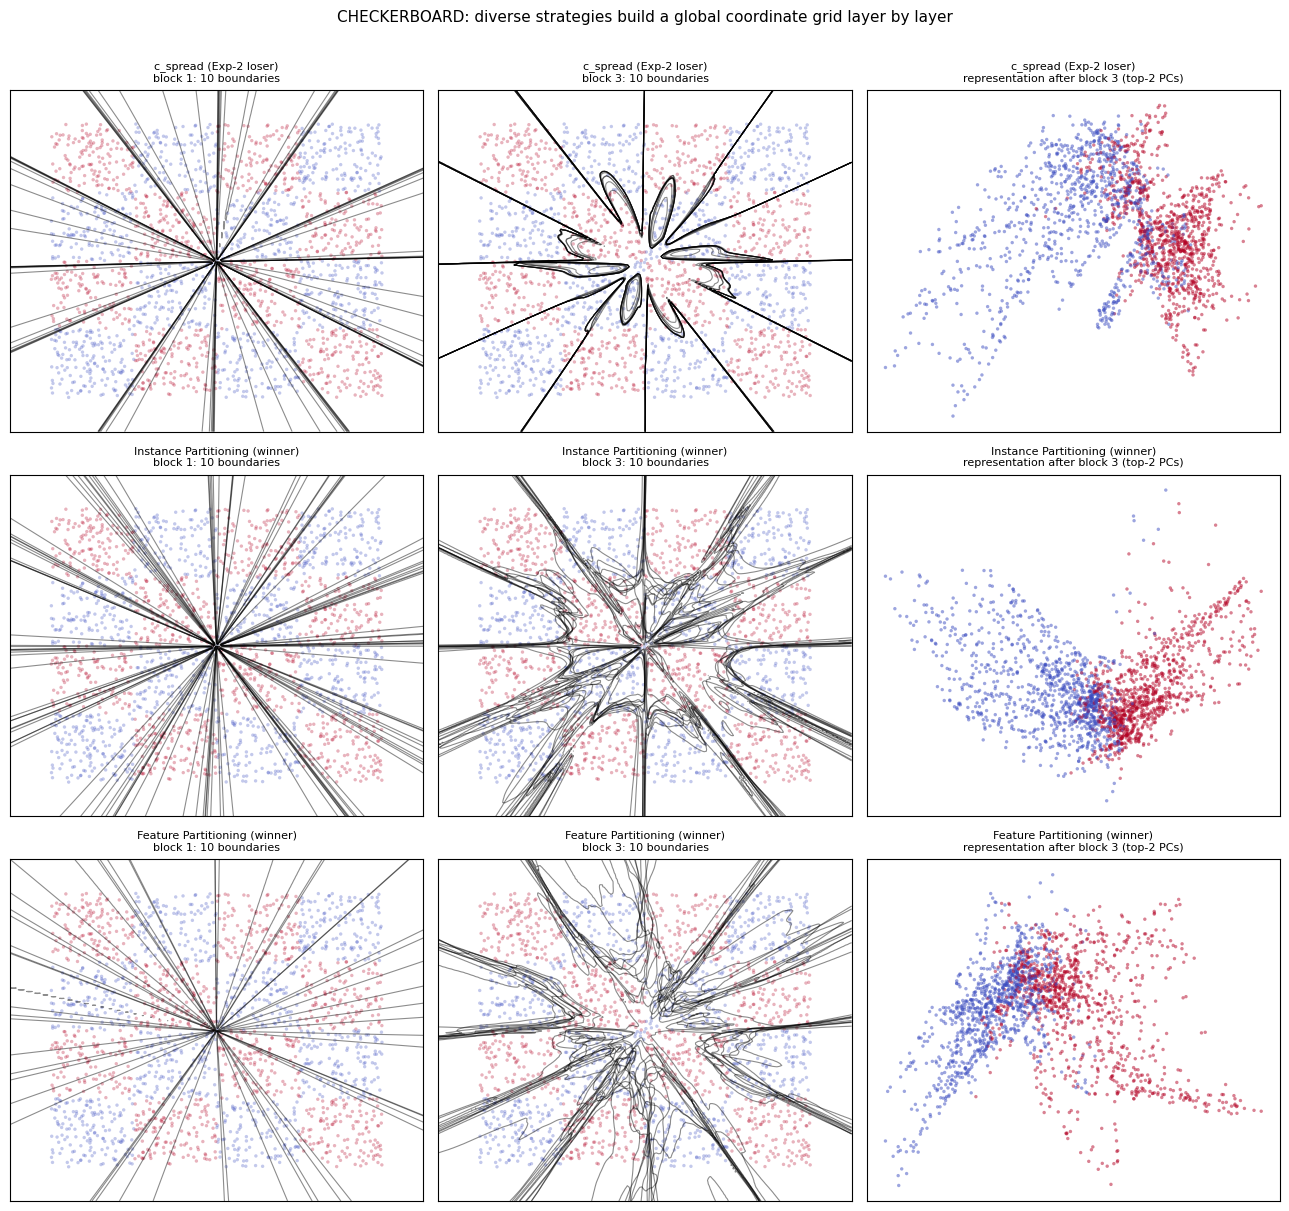

saved fig_feeding_compare_checkerboard.png


In [5]:
draw(Xc, yc, "check", "fig_feeding_compare_checkerboard.png",
     "CHECKERBOARD: diverse strategies build a global coordinate grid layer by layer")

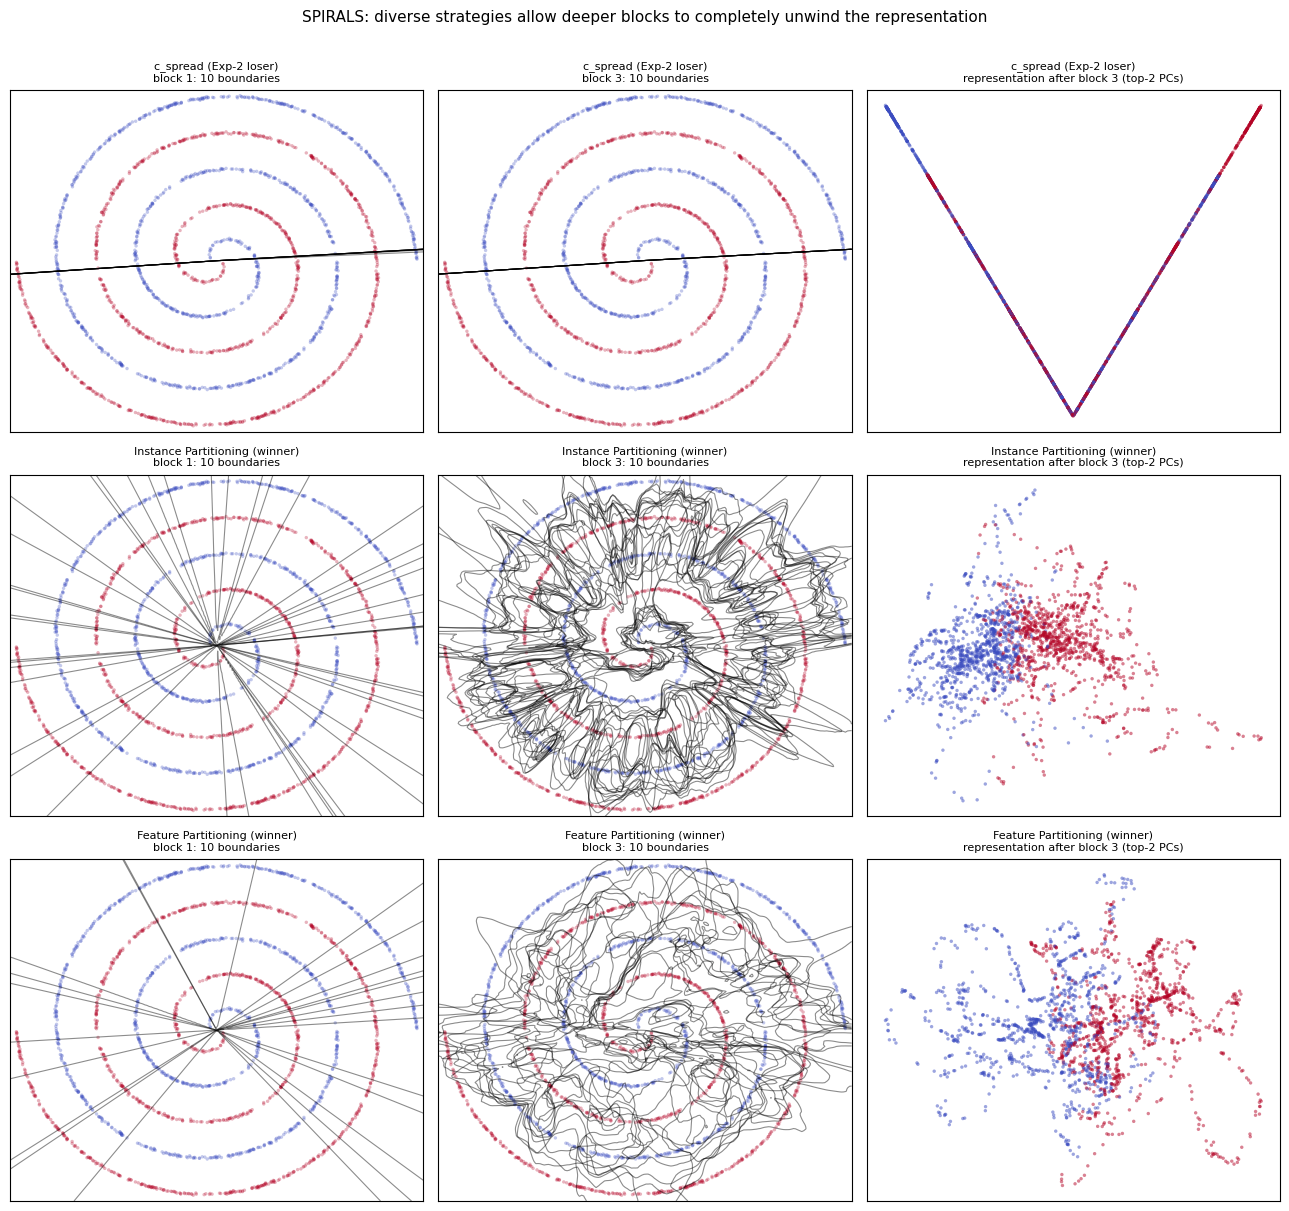

saved fig_feeding_compare_spirals.png


In [6]:
draw(Xs, ys, "spiral", "fig_feeding_compare_spirals.png",
     "SPIRALS: diverse strategies allow deeper blocks to completely unwind the representation")

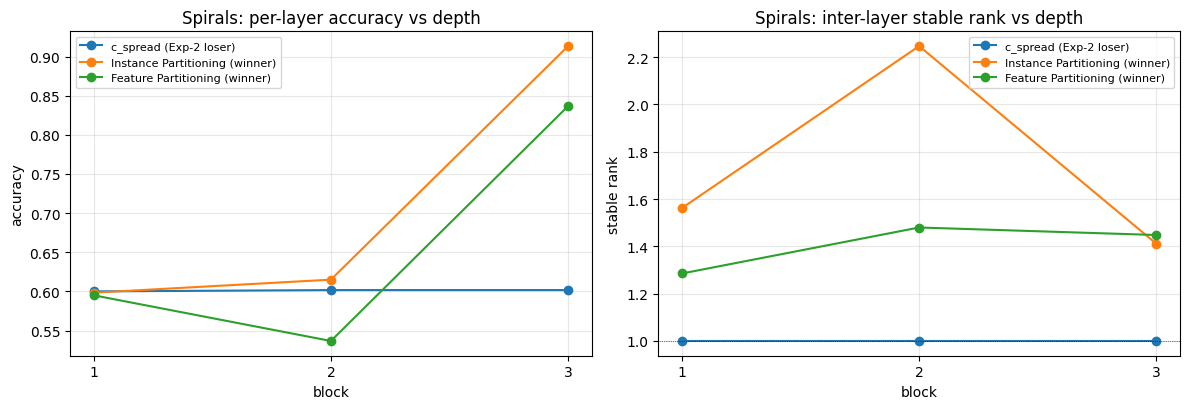

saved fig_feeding_compare_geometric_summary.png


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
Ls = [1, 2, 3]

# We will plot the Spirals for the summary as it's the most dramatic
for strat, name in STRATEGIES:
    d = metrics[("spiral", strat)]
    ax[0].plot(Ls, d["acc"], marker="o", label=name)
    ax[1].plot(Ls, d["rank"], marker="o", label=name)

ax[0].set_title("Spirals: per-layer accuracy vs depth")
ax[0].set_xlabel("block")
ax[0].set_ylabel("accuracy")
ax[0].set_xticks(Ls)
ax[0].grid(alpha=.3)
ax[0].legend(fontsize=8)

ax[1].set_title("Spirals: inter-layer stable rank vs depth")
ax[1].set_xlabel("block")
ax[1].set_ylabel("stable rank")
ax[1].axhline(1, color="k", lw=.5, ls=":")
ax[1].set_xticks(Ls)
ax[1].grid(alpha=.3)
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_feeding_compare_geometric_summary.png", bbox_inches="tight", dpi=130)
plt.show()
print("saved fig_feeding_compare_geometric_summary.png")